# Round 3 풀파워 — 4 Backbone × 5 Aug × KD Ablation (20 Variants)

> 목표: Round 1 (89.25, MBv3-S+KD+horizontal blur) baseline 위에 **horizontal→vertical kernel fix + 20 variants 풀 학습 + 20개 INT8 PTQ 전수 비교** 로 ≥ 93점 진입.

## 20 Variants (4 backbone × 5 aug stack)

| | **MBv3-Small** (2.5M, 67.4%) | **MBv4-Conv-Small** (3.8M, 73.8%) | **RepViT-M0.9** (5.1M, 78.7%) | **GhostNetV3** (5.5M, 77.1%) |
|---|---|---|---|---|
| **A. Combined + KD** (TrivAug+VertBlur+AugMix) | V01 | V02 | V03 | V04 |
| **B. Smalldata + KD** (V_combined + Mixup α=0.2 + CutMix α=1.0 + RandomErasing) | V05 | V06 | V07 | V08 |
| **C. Industrial + KD** (V_combined + Brightness/Contrast + JPEG q=50~95 + GaussNoise) | V09 | V10 | V11 | V12 |
| **D. Manifold Mixup + KD** (V_combined + Manifold Mixup at penultimate, β=2.0) | V13 | V14 | V15 | V16 |
| **E. Combined NO-KD** (control — KD ablation) | V17 | V18 | V19 | V20 |

## Common config

- Image **192** (Round 1 일치) · Epoch **30** · Batch 32
- Optimizer AdamW(lr=7e-4, wd=1e-4) · CosineAnnealing
- KD: ResNet50 teacher 8 epoch + student 30 epoch (α=0.4, T=3.0)
- Seed 42 deterministic

## ⚠️ Best 선정 정책 (Round 2 V6 망함의 교훈)

[[finding-round2-domain-gap-2026-05-07]] §Anomaly: clean val 180장은 **saturation 가능 (val_f1=1.0)**. clean→blur 25%p gap.

### Multi-stage tie-break (사용자 질문 "f1=1.0이면 어떻게?")

**학습 epoch 내부**: `val_f1 max → tie면 train_loss min`

**학습 끝난 후 best variant 선정 (variant 간)**:
1. `val_blur_f1` max ⭐ (motion blur 합성 val 180. clean saturation 회피)
2. tie면 `val_f1` max
3. tie면 `score (blur proxy)` max
4. tie면 `t_inf` min
5. tie면 `train_loss` min

## 🗜️ 20 Variants 전수 Quantization 정책 (사용자 요구 2026-05-08)

[[finding-int8-ptq-v6-2026-05-07]]: fp32 best ≠ INT8 best 가능. backbone별 INT8 친화도 다름.

→ **20 variants 모두 학습 → 20개 fp32 .pth**
→ **20개 전부 INT8 PTQ FX static x86 적용** = 20개 INT8
→ **fp32 20 + INT8 20 = 총 40 candidates** → 통합 multi-stage tie-break으로 진짜 best
→ 진짜 best의 csv가 최종 `submission.csv`

## 학습 시간 추정

- 20 variants × 30 epoch (학습) ≈ 4~5h
- + teacher ResNet50 8 epoch ≈ 30min
- + 20 variants × INT8 PTQ (calibration + eval + inference) ≈ 30~60min
- **총 ≈ 5~7시간** (mps 기준)
- 부담 시 `cfg.EPOCHS` 를 줄이거나 `cfg.VARIANTS`를 sub-list로 잘라 단계 실행

In [ ]:
# Colab 또는 새 환경에서 실행 시 아래 라인 활성화 (통합 환경 — implementation/requirements.txt)
%pip install -q -r ../../requirements.txt


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# === Imports + seed ===
import os, sys, json, time, copy, random, math, warnings
from pathlib import Path
from dataclasses import dataclass, field
from typing import List, Dict, Optional
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.datasets import ImageFolder
from PIL import Image
import cv2
import timm
from sklearn.metrics import f1_score, confusion_matrix
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

warnings.filterwarnings('ignore', category=UserWarning)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ['PYTHONHASHSEED'] = str(SEED)

DEVICE = torch.device('mps') if torch.backends.mps.is_available() else (torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu'))
MP_CONTEXT = None
print(f'🚀 DEVICE = {DEVICE}')
print(f'   torch={torch.__version__}, timm={timm.__version__}, cv2={cv2.__version__}')

🚀 DEVICE = mps
   torch=2.11.0, timm=1.0.15, cv2=4.13.0


In [3]:
# === Config & Paths ===
@dataclass
class Config:
    BASE: str = '/Users/sangyub/Downloads/Smart-Factory_AI_Challenge/smart-factory_obisian/raw/competition/2026-1-machine-learning-in-prace'
    OUT_DIR: str = '/Users/sangyub/Downloads/Smart-Factory_AI_Challenge/smart-factory_obisian/implementation/experiments/round3-fullpower-2026-05-08'
    INPUT_SIZE: int = 192
    EPOCHS: int = 20
    BATCH_SIZE: int = 32
    LR: float = 7e-4
    WEIGHT_DECAY: float = 1e-4
    NUM_WORKERS: int = 0
    AUGMIX_LAMBDA: float = 12.0
    TEACHER_NAME: str = 'resnet50'
    TEACHER_EPOCHS: int = 20
    TEACHER_LR: float = 3e-4
    KD_ALPHA: float = 0.4
    KD_TEMP: float = 3.0
    LABEL_SMOOTHING: float = 0.05
    VARIANTS: List[str] = field(default_factory=lambda: [
        'V01_mbv3s_combined_KD',     'V02_mbv4cs_combined_KD',
        'V03_repvit_combined_KD',    'V04_ghostnet_combined_KD',
        'V05_mbv3s_smalldata_KD',    'V06_mbv4cs_smalldata_KD',
        'V07_repvit_smalldata_KD',   'V08_ghostnet_smalldata_KD',
        'V09_mbv3s_industrial_KD',   'V10_mbv4cs_industrial_KD',
        'V11_repvit_industrial_KD',  'V12_ghostnet_industrial_KD',
        'V13_mbv3s_manifold_KD',     'V14_mbv4cs_manifold_KD',
        'V15_repvit_manifold_KD',    'V16_ghostnet_manifold_KD',
        'V17_mbv3s_no_KD',           'V18_mbv4cs_no_KD',
        'V19_repvit_no_KD',          'V20_ghostnet_no_KD',
    ])

cfg = Config()
os.makedirs(cfg.OUT_DIR, exist_ok=True)

from datetime import datetime
RUN_ID = datetime.now().strftime('%Y%m%d_%H%M%S')
RUNS_DIR = os.path.join(cfg.OUT_DIR, 'runs')
LEADERBOARD_PATH = os.path.join(cfg.OUT_DIR, 'leaderboard.json')
os.makedirs(RUNS_DIR, exist_ok=True)
for _v in cfg.VARIANTS:
    os.makedirs(os.path.join(RUNS_DIR, _v), exist_ok=True)
print(f'🆔 RUN_ID = {RUN_ID}')
print(f'📂 OUT_DIR = {cfg.OUT_DIR}')
print(f'📊 Total variants = {len(cfg.VARIANTS)}')

TRAIN_DIR = f'{cfg.BASE}/competition_dataset/NEU-DET_open/train/images'
VAL_DIR   = f'{cfg.BASE}/competition_dataset/NEU-DET_open/validation/images'
DUMMY_DIR = f'{cfg.BASE}/competition_dataset/NEU-DET_open/test/images'
REAL_DIR  = f'{cfg.BASE}/test/test/images'
print('Path check:')
for n, p in [('train', TRAIN_DIR), ('val', VAL_DIR), ('dummy', DUMMY_DIR), ('real', REAL_DIR)]:
    print(f'  {n:6s}: {os.path.isdir(p)}  ({p})')

CLASSES = sorted([d for d in os.listdir(TRAIN_DIR) if not d.startswith('.') and os.path.isdir(os.path.join(TRAIN_DIR, d))])
NUM_CLASSES = len(CLASSES)
print(f'📋 CLASSES = {CLASSES}  (num_classes={NUM_CLASSES})')

🆔 RUN_ID = 20260508_022012
📂 OUT_DIR = /Users/sangyub/Downloads/Smart-Factory_AI_Challenge/smart-factory_obisian/implementation/experiments/round3-fullpower-2026-05-08
📊 Total variants = 20
Path check:
  train : True  (/Users/sangyub/Downloads/Smart-Factory_AI_Challenge/smart-factory_obisian/raw/competition/2026-1-machine-learning-in-prace/competition_dataset/NEU-DET_open/train/images)
  val   : True  (/Users/sangyub/Downloads/Smart-Factory_AI_Challenge/smart-factory_obisian/raw/competition/2026-1-machine-learning-in-prace/competition_dataset/NEU-DET_open/validation/images)
  dummy : True  (/Users/sangyub/Downloads/Smart-Factory_AI_Challenge/smart-factory_obisian/raw/competition/2026-1-machine-learning-in-prace/competition_dataset/NEU-DET_open/test/images)
  real  : True  (/Users/sangyub/Downloads/Smart-Factory_AI_Challenge/smart-factory_obisian/raw/competition/2026-1-machine-learning-in-prace/test/test/images)
📋 CLASSES = ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-i

In [4]:
# === Variant routing — backbone × aug type × KD ===
BACKBONE_TIMM = {
    'mbv3s':    'mobilenetv3_small_100',
    'mbv4cs':   'mobilenetv4_conv_small.e2400_r224_in1k',
    'repvit':   'repvit_m0_9.dist_450e_in1k',
    'ghostnet': 'ghostnetv3_100.in1k',
}
BACKBONE_LIST = ['mbv3s', 'mbv4cs', 'repvit', 'ghostnet']
AUG_LIST = ['combined', 'smalldata', 'industrial', 'manifold', 'no_KD']

AUG_GROUP_SPEC = {
    'combined':   dict(input_mixup=None,            feat_mixup=None,       random_erase=False, industrial=False, augmix=True,  use_kd=True),
    'smalldata':  dict(input_mixup='mixup_cutmix',  feat_mixup=None,       random_erase=True,  industrial=False, augmix=False, use_kd=True),
    'industrial': dict(input_mixup=None,            feat_mixup=None,       random_erase=False, industrial=True,  augmix=False, use_kd=True),
    'manifold':   dict(input_mixup=None,            feat_mixup='manifold', random_erase=False, industrial=False, augmix=True,  use_kd=True),
    'no_KD':      dict(input_mixup=None,            feat_mixup=None,       random_erase=False, industrial=False, augmix=True,  use_kd=False),
}

def parse_variant(v):
    parts = v.split('_')
    bb = parts[1]
    if parts[2] == 'no':
        return bb, 'no_KD'
    return bb, parts[2]

VARIANT_BACKBONES: Dict[str, str] = {v: BACKBONE_TIMM[parse_variant(v)[0]] for v in cfg.VARIANTS}
VARIANT_AUG_GROUP: Dict[str, str] = {v: parse_variant(v)[1] for v in cfg.VARIANTS}
VARIANT_USE_KD:    Dict[str, bool] = {v: AUG_GROUP_SPEC[VARIANT_AUG_GROUP[v]]['use_kd'] for v in cfg.VARIANTS}
USE_INPUT_MIXUP:   Dict[str, Optional[str]] = {v: AUG_GROUP_SPEC[VARIANT_AUG_GROUP[v]]['input_mixup'] for v in cfg.VARIANTS}
USE_FEATURE_MIXUP: Dict[str, Optional[str]] = {v: AUG_GROUP_SPEC[VARIANT_AUG_GROUP[v]]['feat_mixup'] for v in cfg.VARIANTS}

print('🔀 Variant routing (20 variants):')
for v in cfg.VARIANTS:
    bb_short = parse_variant(v)[0]
    aug = VARIANT_AUG_GROUP[v]
    kd = '✅' if VARIANT_USE_KD[v] else '❌'
    im = USE_INPUT_MIXUP[v] or '-'
    fm = USE_FEATURE_MIXUP[v] or '-'
    print(f'  {v:32s}  backbone={bb_short:9s}  aug={aug:10s}  KD={kd}  in_mix={im:14s}  feat_mix={fm}')

🔀 Variant routing (20 variants):
  V01_mbv3s_combined_KD             backbone=mbv3s      aug=combined    KD=✅  in_mix=-               feat_mix=-
  V02_mbv4cs_combined_KD            backbone=mbv4cs     aug=combined    KD=✅  in_mix=-               feat_mix=-
  V03_repvit_combined_KD            backbone=repvit     aug=combined    KD=✅  in_mix=-               feat_mix=-
  V04_ghostnet_combined_KD          backbone=ghostnet   aug=combined    KD=✅  in_mix=-               feat_mix=-
  V05_mbv3s_smalldata_KD            backbone=mbv3s      aug=smalldata   KD=✅  in_mix=mixup_cutmix    feat_mix=-
  V06_mbv4cs_smalldata_KD           backbone=mbv4cs     aug=smalldata   KD=✅  in_mix=mixup_cutmix    feat_mix=-
  V07_repvit_smalldata_KD           backbone=repvit     aug=smalldata   KD=✅  in_mix=mixup_cutmix    feat_mix=-
  V08_ghostnet_smalldata_KD         backbone=ghostnet   aug=smalldata   KD=✅  in_mix=mixup_cutmix    feat_mix=-
  V09_mbv3s_industrial_KD           backbone=mbv3s      aug=industrial 

In [5]:
# === Vertical Motion Blur (custom transform) ===
# ⚠️ Round 1 baseline은 horizontal kernel 사용 — Round 3에서 vertical로 fix.
class VerticalMotionBlur:
    """Linear motion blur, angle ~ 90° ± 5°, kernel size random in [k_min, k_max]."""
    def __init__(self, p=0.7, k_min=3, k_max=31):
        self.p, self.k_min, self.k_max = p, k_min, k_max

    def __call__(self, img_pil):
        if np.random.rand() > self.p:
            return img_pil
        k = int(np.random.choice(range(self.k_min, self.k_max + 1, 2)))
        angle = 90.0 + float(np.random.uniform(-5, 5))
        kernel = np.zeros((k, k), dtype=np.float32)
        cv2.line(kernel, (k // 2, 0), (k // 2, k - 1), 1.0, thickness=1)
        M = cv2.getRotationMatrix2D((k / 2, k / 2), angle - 90, 1.0)
        kernel = cv2.warpAffine(kernel, M, (k, k))
        s = float(kernel.sum())
        kernel = kernel / max(s, 1e-6)
        arr = np.asarray(img_pil)
        out = cv2.filter2D(arr, -1, kernel)
        return Image.fromarray(out)

class IndustrialCorruption:
    """5m/s 컨베이어 도메인 corruption (concept-industrial-conveyor-aug)."""
    def __init__(self, p=0.5):
        self.p = p
    def __call__(self, img_pil):
        arr = np.asarray(img_pil).astype(np.float32) / 255.0
        if np.random.rand() < self.p:
            br = np.random.uniform(-0.20, 0.20)
            ct = np.random.uniform(-0.15, 0.15)
            arr = np.clip((arr - 0.5) * (1 + ct) + 0.5 + br, 0, 1)
        if np.random.rand() < self.p:
            sigma = np.random.uniform(0.01, 0.03)
            arr = np.clip(arr + np.random.randn(*arr.shape) * sigma, 0, 1)
        out = (arr * 255).astype(np.uint8)
        img = Image.fromarray(out)
        if np.random.rand() < self.p:
            q = int(np.random.uniform(50, 95))
            from io import BytesIO
            buf = BytesIO()
            img.save(buf, format='JPEG', quality=q)
            buf.seek(0); img = Image.open(buf).copy()
        return img

_t = Image.fromarray(np.random.randint(0, 256, (200, 200, 3), dtype=np.uint8))
print('VerticalMotionBlur:', VerticalMotionBlur(p=1.0)(_t).size)
print('IndustrialCorruption:', IndustrialCorruption(p=1.0)(_t).size)

VerticalMotionBlur: (200, 200)
IndustrialCorruption: (200, 200)


In [6]:
# === Transform pipelines per variant ===
NORMALIZE = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
RESIZE = T.Resize((cfg.INPUT_SIZE, cfg.INPUT_SIZE))
TO_TENSOR_NORM = T.Compose([T.ToTensor(), NORMALIZE])
EVAL_TF = T.Compose([RESIZE, T.ToTensor(), NORMALIZE])

AUG_STACKS = {
    'combined': T.Compose([
        RESIZE, T.RandomHorizontalFlip(p=0.5), T.TrivialAugmentWide(),
        VerticalMotionBlur(p=0.7, k_min=3, k_max=31),
    ]),
    'smalldata': T.Compose([
        RESIZE, T.RandomHorizontalFlip(p=0.5), T.TrivialAugmentWide(),
        VerticalMotionBlur(p=0.7, k_min=3, k_max=31),
    ]),
    'industrial': T.Compose([
        RESIZE, T.RandomHorizontalFlip(p=0.5), T.TrivialAugmentWide(),
        VerticalMotionBlur(p=0.7, k_min=3, k_max=31),
        IndustrialCorruption(p=0.5),
    ]),
    'manifold': T.Compose([
        RESIZE, T.RandomHorizontalFlip(p=0.5), T.TrivialAugmentWide(),
        VerticalMotionBlur(p=0.7, k_min=3, k_max=31),
    ]),
    'no_KD': T.Compose([
        RESIZE, T.RandomHorizontalFlip(p=0.5), T.TrivialAugmentWide(),
        VerticalMotionBlur(p=0.7, k_min=3, k_max=31),
    ]),
}

BASE_AUGS    = {v: AUG_STACKS[VARIANT_AUG_GROUP[v]] for v in cfg.VARIANTS}
USE_AUGMIX   = {v: AUG_GROUP_SPEC[VARIANT_AUG_GROUP[v]]['augmix'] for v in cfg.VARIANTS}
USE_RANDOM_ERASE = {v: AUG_GROUP_SPEC[VARIANT_AUG_GROUP[v]]['random_erase'] for v in cfg.VARIANTS}

RANDOM_ERASING = T.RandomErasing(p=0.25, scale=(0.02, 0.10), ratio=(0.3, 3.3), value=0)

try:
    AUGMIX_TF = T.AugMix(severity=3, mixture_width=3, chain_depth=-1, alpha=1.0)
    print('torchvision AugMix OK')
except Exception as e:
    print(f'⚠️ AugMix not available: {e}')
    AUGMIX_TF = T.Compose([])

print(f'BASE_AUGS = {len(BASE_AUGS)} variants  (5 unique aug stacks × 4 backbone)')

torchvision AugMix OK
BASE_AUGS = 20 variants  (5 unique aug stacks × 4 backbone)


In [7]:
# === Datasets + DataLoaders (val_blur_loader 포함) ===
class TrainDataset(Dataset):
    def __init__(self, root, base_aug, use_augmix, use_random_erasing=False):
        self.imgs = ImageFolder(root)
        self.base_aug = base_aug
        self.use_augmix = use_augmix
        self.use_random_erasing = use_random_erasing
    def __len__(self):
        return len(self.imgs)
    def __getitem__(self, i):
        img, y = self.imgs[i]
        img_aug = self.base_aug(img)
        x = TO_TENSOR_NORM(img_aug)
        if self.use_random_erasing:
            x = RANDOM_ERASING(x)
        if self.use_augmix:
            x1 = TO_TENSOR_NORM(AUGMIX_TF(img_aug))
            x2 = TO_TENSOR_NORM(AUGMIX_TF(img_aug))
            return x, x1, x2, y
        return x, y

class RealTestDataset(Dataset):
    def __init__(self, root, transform):
        self.files = sorted([f for f in os.listdir(root) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        self.root = root; self.transform = transform
    def __len__(self):
        return len(self.files)
    def __getitem__(self, i):
        fname = self.files[i]
        img = Image.open(os.path.join(self.root, fname)).convert('RGB')
        return self.transform(img), fname

# === val_blur_loader — motion blur 합성 val ⭐
# Reference: finding-round2-domain-gap-2026-05-07 §추천 #3
# val 180장(clean)에 VerticalMotionBlur(p=1.0, k=[3,31] random) 합성 → test 분포 proxy
# 학습 시 X. best variant 선정 시 사용. clean val saturation(val_f1=1.0) 회피.
BLUR_EVAL_TF = T.Compose([
    RESIZE,
    VerticalMotionBlur(p=1.0, k_min=3, k_max=31),
    T.ToTensor(),
    NORMALIZE,
])
class BlurredImageFolder(Dataset):
    """ImageFolder + deterministic blur (seed = base_seed + i)."""
    def __init__(self, root, transform, seed=42):
        self.imgs = ImageFolder(root)
        self.transform = transform
        self.seed = seed
    def __len__(self):
        return len(self.imgs)
    def __getitem__(self, i):
        np.random.seed(self.seed + i); random.seed(self.seed + i)
        img, y = self.imgs[i]
        return self.transform(img), y

def worker_init(worker_id):
    np.random.seed(SEED + worker_id)
    random.seed(SEED + worker_id)

val_loader = DataLoader(ImageFolder(VAL_DIR, transform=EVAL_TF),
                        batch_size=cfg.BATCH_SIZE, shuffle=False,
                        num_workers=cfg.NUM_WORKERS, worker_init_fn=worker_init)
val_blur_loader = DataLoader(BlurredImageFolder(VAL_DIR, BLUR_EVAL_TF, seed=SEED),
                             batch_size=cfg.BATCH_SIZE, shuffle=False,
                             num_workers=cfg.NUM_WORKERS, worker_init_fn=worker_init)
dummy_loader = DataLoader(ImageFolder(DUMMY_DIR, transform=EVAL_TF),
                          batch_size=cfg.BATCH_SIZE, shuffle=False,
                          num_workers=cfg.NUM_WORKERS, worker_init_fn=worker_init)
real_loader = DataLoader(RealTestDataset(REAL_DIR, EVAL_TF),
                         batch_size=cfg.BATCH_SIZE, shuffle=False,
                         num_workers=cfg.NUM_WORKERS, worker_init_fn=worker_init)
print(f'Val(clean): {len(val_loader.dataset)} | Val(blur proxy): {len(val_blur_loader.dataset)} | Dummy: {len(dummy_loader.dataset)} | Real test: {len(real_loader.dataset)}')
print('  ⭐ val_blur_loader = motion blur 합성 val 180 (clean saturation 회피용 best 선정 proxy)')

Val(clean): 180 | Val(blur proxy): 180 | Dummy: 12 | Real test: 180
  ⭐ val_blur_loader = motion blur 합성 val 180 (clean saturation 회피용 best 선정 proxy)


In [8]:
# === Eval functions + competition score + leaderboard ===
def js_div(logits_list):
    probs = [F.softmax(p, dim=-1) for p in logits_list]
    p_mean = sum(probs) / len(probs)
    p_mean = torch.clamp(p_mean, 1e-7, 1.0)
    js = 0.0
    for p in logits_list:
        js = js + F.kl_div(F.log_softmax(p, dim=-1), p_mean, reduction='batchmean')
    return js / len(logits_list)

@torch.no_grad()
def eval_macro_f1(model, loader, device=None):
    device = device or DEVICE
    model.eval()
    ys, ps = [], []
    for x, y in loader:
        x = x.to(device)
        out = model(x).argmax(-1).cpu().numpy()
        ys.append(y.numpy()); ps.append(out)
    return f1_score(np.concatenate(ys), np.concatenate(ps), average='macro')

@torch.no_grad()
def eval_with_details(model, loader, device=None):
    device = device or DEVICE
    model.eval()
    ys, ps = [], []
    for x, y in loader:
        x = x.to(device)
        out = model(x).argmax(-1).cpu().numpy()
        ys.append(y.numpy()); ps.append(out)
    y = np.concatenate(ys); p = np.concatenate(ps)
    macro = f1_score(y, p, average='macro')
    per_cls = f1_score(y, p, average=None, zero_division=0, labels=list(range(NUM_CLASSES)))
    cm = confusion_matrix(y, p, labels=list(range(NUM_CLASSES)))
    return macro, per_cls, cm

def compute_competition_score(macro_f1, t_inf_sec):
    """신룰 (2026-05-06): Final = max(0, F1×100 - max(0, (T-1)×2.5)). T>30s 실격."""
    if t_inf_sec > 30.0:
        return 0.0, '실격 (T>30s)'
    penalty = max(0.0, (t_inf_sec - 1.0) * 2.5)
    score = max(0.0, macro_f1 * 100 - penalty)
    return score, f'penalty={penalty:.2f}'

def load_leaderboard():
    if not os.path.exists(LEADERBOARD_PATH):
        return {'runs': []}
    with open(LEADERBOARD_PATH) as f:
        return json.load(f)

def save_leaderboard(lb):
    with open(LEADERBOARD_PATH, 'w') as f:
        json.dump(lb, f, indent=2)

print('Eval + leaderboard helpers ready')

Eval + leaderboard helpers ready


In [9]:
# === Variant-aware make_model + KD teacher 학습 ===
def make_model(variant_name=None):
    name = VARIANT_BACKBONES.get(variant_name, 'mobilenetv3_small_100') if variant_name else 'mobilenetv3_small_100'
    try:
        return timm.create_model(name, num_classes=NUM_CLASSES, pretrained=True)
    except Exception as e:
        print(f'⚠️ timm.create_model({name}) 실패: {e}')
        print('   → fallback: mobilenetv4_conv_small.e2400_r224_in1k')
        return timm.create_model('mobilenetv4_conv_small.e2400_r224_in1k', num_classes=NUM_CLASSES, pretrained=True)

def make_teacher():
    """ResNet50 IMAGENET1K_V2 — Round 1 일치."""
    from torchvision import models
    weights = models.ResNet50_Weights.IMAGENET1K_V2
    m = models.resnet50(weights=weights)
    m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
    return m

def kd_loss(student_logits, teacher_logits, labels, alpha, temperature, label_smoothing=0.0):
    ce = F.cross_entropy(student_logits, labels, label_smoothing=label_smoothing)
    if teacher_logits is None:
        return ce
    kd = F.kl_div(
        F.log_softmax(student_logits / temperature, dim=1),
        F.softmax(teacher_logits / temperature, dim=1),
        reduction='batchmean',
    ) * (temperature ** 2)
    return alpha * ce + (1 - alpha) * kd

def train_teacher():
    """ResNet50 8 epoch (Round 1 setup)."""
    print('🎓 Training teacher (ResNet50, 8 epoch, V_combined aug)...')
    torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
    teacher_aug = AUG_STACKS['combined']
    teacher_ds = TrainDataset(TRAIN_DIR, teacher_aug, use_augmix=False)
    teacher_loader = DataLoader(teacher_ds, batch_size=cfg.BATCH_SIZE, shuffle=True,
                                 num_workers=cfg.NUM_WORKERS, worker_init_fn=worker_init,
                                 drop_last=True)
    teacher = make_teacher().to(DEVICE)
    opt = torch.optim.AdamW(teacher.parameters(), lr=cfg.TEACHER_LR, weight_decay=cfg.WEIGHT_DECAY)
    best_val_f1 = -1.0; best_state = None; best_epoch = -1; best_train_loss = float('inf')
    for epoch in range(cfg.TEACHER_EPOCHS):
        teacher.train(); running = 0.0; n = 0
        for x, y in teacher_loader:
            x = x.to(DEVICE); y = y.to(DEVICE)
            opt.zero_grad()
            logits = teacher(x)
            loss = F.cross_entropy(logits, y, label_smoothing=cfg.LABEL_SMOOTHING)
            loss.backward(); opt.step()
            running += loss.item() * y.size(0); n += y.size(0)
        train_loss = running / max(n, 1)
        val_f1 = eval_macro_f1(teacher, val_loader)
        marker = ''
        if val_f1 > best_val_f1 or (val_f1 == best_val_f1 and train_loss < best_train_loss):
            best_val_f1 = val_f1; best_train_loss = train_loss; best_epoch = epoch + 1
            best_state = copy.deepcopy(teacher.state_dict())
            marker = ' ⭐ BEST'
        print(f'  [teacher] epoch {epoch+1:02d}/{cfg.TEACHER_EPOCHS}  loss={train_loss:.4f}  val_f1={val_f1:.4f}{marker}')
    teacher.load_state_dict(best_state)
    teacher.eval()
    for p in teacher.parameters():
        p.requires_grad = False
    teacher_path = os.path.join(cfg.OUT_DIR, 'model_teacher.pth')
    torch.save({'state_dict': best_state, 'best_val_f1': best_val_f1, 'best_epoch': best_epoch}, teacher_path)
    print(f'  💾 teacher saved: {teacher_path}  (best_epoch={best_epoch}, val_f1={best_val_f1:.4f})')
    return teacher

teacher_model = train_teacher()

🎓 Training teacher (ResNet50, 8 epoch, V_combined aug)...
  [teacher] epoch 01/20  loss=0.8476  val_f1=0.9220 ⭐ BEST
  [teacher] epoch 02/20  loss=0.4824  val_f1=0.9341 ⭐ BEST
  [teacher] epoch 03/20  loss=0.4287  val_f1=0.9831 ⭐ BEST
  [teacher] epoch 04/20  loss=0.4126  val_f1=0.9660
  [teacher] epoch 05/20  loss=0.4002  val_f1=0.9662
  [teacher] epoch 06/20  loss=0.3705  val_f1=0.9944 ⭐ BEST
  [teacher] epoch 07/20  loss=0.3621  val_f1=0.9944 ⭐ BEST
  [teacher] epoch 08/20  loss=0.3570  val_f1=1.0000 ⭐ BEST
  [teacher] epoch 09/20  loss=0.3267  val_f1=0.9600
  [teacher] epoch 10/20  loss=0.3532  val_f1=1.0000 ⭐ BEST
  [teacher] epoch 11/20  loss=0.3555  val_f1=0.9720
  [teacher] epoch 12/20  loss=0.3360  val_f1=1.0000 ⭐ BEST
  [teacher] epoch 13/20  loss=0.3106  val_f1=1.0000 ⭐ BEST
  [teacher] epoch 14/20  loss=0.3269  val_f1=1.0000
  [teacher] epoch 15/20  loss=0.3216  val_f1=0.9774
  [teacher] epoch 16/20  loss=0.3297  val_f1=0.9944
  [teacher] epoch 17/20  loss=0.3308  val_f1=0.

In [10]:
# === Mixup + CutMix utilities (smalldata aug group) ===
def mixup_data(x, y, alpha=0.2):
    lam = float(np.random.beta(alpha, alpha)) if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0), device=x.device)
    mixed = lam * x + (1 - lam) * x[idx]
    return mixed, y, y[idx], lam

def cutmix_data(x, y, alpha=1.0):
    lam = float(np.random.beta(alpha, alpha)) if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0), device=x.device)
    _, _, H, W = x.shape
    cut_rat = np.sqrt(1 - lam)
    cut_w = int(W * cut_rat); cut_h = int(H * cut_rat)
    cx = np.random.randint(W); cy = np.random.randint(H)
    bbx1 = max(0, cx - cut_w // 2); bbx2 = min(W, cx + cut_w // 2)
    bby1 = max(0, cy - cut_h // 2); bby2 = min(H, cy + cut_h // 2)
    mixed = x.clone()
    mixed[:, :, bby1:bby2, bbx1:bbx2] = x[idx, :, bby1:bby2, bbx1:bbx2]
    lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (W * H))
    return mixed, y, y[idx], lam

print('Mixup + CutMix helpers ready')

Mixup + CutMix helpers ready


In [11]:
# === Default train_variant (KD + tie-break) ===
def train_variant(variant_name, train_ds):
    torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
    use_augmix = USE_AUGMIX[variant_name]
    use_kd = VARIANT_USE_KD[variant_name]
    input_mixup = USE_INPUT_MIXUP[variant_name]
    train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True,
                              num_workers=cfg.NUM_WORKERS, worker_init_fn=worker_init,
                              drop_last=True)
    model = make_model(variant_name).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg.EPOCHS)
    history = {'train_loss': [], 'val_f1': []}

    best_val_f1 = -1.0
    best_train_loss = float('inf')
    best_epoch = -1
    best_state = None

    for epoch in range(cfg.EPOCHS):
        model.train(); running = 0.0; n = 0
        for batch in train_loader:
            opt.zero_grad()
            if use_augmix:
                x, x1, x2, y = batch
                x  = x.to(DEVICE); x1 = x1.to(DEVICE); x2 = x2.to(DEVICE); y = y.to(DEVICE)
            else:
                x, y = batch
                x = x.to(DEVICE); y = y.to(DEVICE)

            if input_mixup == 'mixup_cutmix':
                if np.random.rand() < 0.5:
                    x_mix, y_a, y_b, lam = mixup_data(x, y, alpha=0.2)
                else:
                    x_mix, y_a, y_b, lam = cutmix_data(x, y, alpha=1.0)
                p = model(x_mix)
                if use_kd:
                    with torch.no_grad():
                        t_logits = teacher_model(x)
                    ce_a = F.cross_entropy(p, y_a, label_smoothing=cfg.LABEL_SMOOTHING)
                    ce_b = F.cross_entropy(p, y_b, label_smoothing=cfg.LABEL_SMOOTHING)
                    ce_mix = lam * ce_a + (1 - lam) * ce_b
                    p_orig = model(x)
                    kd = F.kl_div(F.log_softmax(p_orig / cfg.KD_TEMP, dim=1),
                                  F.softmax(t_logits / cfg.KD_TEMP, dim=1),
                                  reduction='batchmean') * (cfg.KD_TEMP ** 2)
                    loss = cfg.KD_ALPHA * ce_mix + (1 - cfg.KD_ALPHA) * kd
                else:
                    ce_a = F.cross_entropy(p, y_a, label_smoothing=cfg.LABEL_SMOOTHING)
                    ce_b = F.cross_entropy(p, y_b, label_smoothing=cfg.LABEL_SMOOTHING)
                    loss = lam * ce_a + (1 - lam) * ce_b
            else:
                p = model(x)
                t_logits = None
                if use_kd:
                    with torch.no_grad():
                        t_logits = teacher_model(x)
                loss = kd_loss(p, t_logits, y, cfg.KD_ALPHA, cfg.KD_TEMP,
                              label_smoothing=cfg.LABEL_SMOOTHING)
                if use_augmix:
                    p1 = model(x1); p2 = model(x2)
                    loss = loss + cfg.AUGMIX_LAMBDA * js_div([p, p1, p2])

            loss.backward(); opt.step()
            running += loss.item() * y.size(0); n += y.size(0)
        sched.step()
        train_loss = running / max(n, 1)
        val_f1 = eval_macro_f1(model, val_loader)
        history['train_loss'].append(train_loss); history['val_f1'].append(val_f1)

        is_better = (val_f1 > best_val_f1) or (val_f1 == best_val_f1 and train_loss < best_train_loss)
        if is_better:
            best_val_f1 = val_f1
            best_train_loss = train_loss
            best_epoch = epoch + 1
            best_state = copy.deepcopy(model.state_dict())
            marker = ' ⭐ BEST'
        else:
            marker = ''
        print(f'  [{variant_name}] epoch {epoch+1:02d}/{cfg.EPOCHS}  loss={train_loss:.4f}  val_f1={val_f1:.4f}{marker}')

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f'  ⭐ Restored BEST epoch {best_epoch}/{cfg.EPOCHS} (val_f1={best_val_f1:.4f}, train_loss={best_train_loss:.4f})')

    ckpt_path = os.path.join(cfg.OUT_DIR, f'model_{variant_name}.pth')
    torch.save({
        'variant': variant_name,
        'backbone': VARIANT_BACKBONES[variant_name],
        'aug_group': VARIANT_AUG_GROUP[variant_name],
        'use_kd': VARIANT_USE_KD[variant_name],
        'state_dict': model.state_dict(),
        'history': history,
        'best_val_f1': best_val_f1,
        'best_train_loss': best_train_loss,
        'best_epoch': best_epoch,
        'epochs_trained': cfg.EPOCHS,
        'config': {k: v for k, v in cfg.__dict__.items() if not k.startswith('_')},
    }, ckpt_path)
    print(f'  💾 checkpoint saved (BEST epoch {best_epoch}): {ckpt_path}')
    hist_path = os.path.join(cfg.OUT_DIR, f'history_{variant_name}.json')
    with open(hist_path, 'w') as f:
        json.dump(history, f)
    dummy_f1 = eval_macro_f1(model, dummy_loader)
    return model, history, dummy_f1

print('train_variant ready (KD + tie-break + Mixup/CutMix routing)')

train_variant ready (KD + tie-break + Mixup/CutMix routing)


In [12]:
# === train_variant_v6_v7 (Manifold Mixup at penultimate features) ===
def train_variant_v6_v7(variant_name, train_ds):
    torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
    use_augmix = USE_AUGMIX[variant_name]
    use_kd = VARIANT_USE_KD[variant_name]
    train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True,
                              num_workers=cfg.NUM_WORKERS, worker_init_fn=worker_init,
                              drop_last=True)
    model = make_model(variant_name).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg.EPOCHS)
    history = {'train_loss': [], 'val_f1': []}
    best_val_f1 = -1.0; best_train_loss = float('inf'); best_epoch = -1; best_state = None
    MIXUP_ALPHA = 2.0

    for epoch in range(cfg.EPOCHS):
        model.train(); running = 0.0; n = 0
        for batch in train_loader:
            opt.zero_grad()
            if use_augmix:
                x, x1, x2, y = batch
                x = x.to(DEVICE); x1 = x1.to(DEVICE); x2 = x2.to(DEVICE); y = y.to(DEVICE)
            else:
                x, y = batch
                x = x.to(DEVICE); y = y.to(DEVICE)

            features = model.forward_features(x)
            perm = torch.randperm(x.size(0), device=DEVICE)
            lam = float(np.random.beta(MIXUP_ALPHA, MIXUP_ALPHA))
            features_mixed = lam * features + (1 - lam) * features[perm]
            output = model.forward_head(features_mixed)
            loss_inter = (lam * F.cross_entropy(output, y, label_smoothing=cfg.LABEL_SMOOTHING)
                          + (1 - lam) * F.cross_entropy(output, y[perm], label_smoothing=cfg.LABEL_SMOOTHING))

            if use_kd:
                p_orig = model(x)
                with torch.no_grad():
                    t_logits = teacher_model(x)
                kd = F.kl_div(F.log_softmax(p_orig / cfg.KD_TEMP, dim=1),
                              F.softmax(t_logits / cfg.KD_TEMP, dim=1),
                              reduction='batchmean') * (cfg.KD_TEMP ** 2)
                loss = cfg.KD_ALPHA * loss_inter + (1 - cfg.KD_ALPHA) * kd
            else:
                loss = loss_inter

            if use_augmix:
                p = model(x); p1 = model(x1); p2 = model(x2)
                loss = loss + cfg.AUGMIX_LAMBDA * js_div([p, p1, p2])

            loss.backward(); opt.step()
            running += loss.item() * y.size(0); n += y.size(0)
        sched.step()
        train_loss = running / max(n, 1)
        val_f1 = eval_macro_f1(model, val_loader)
        history['train_loss'].append(train_loss); history['val_f1'].append(val_f1)

        is_better = (val_f1 > best_val_f1) or (val_f1 == best_val_f1 and train_loss < best_train_loss)
        if is_better:
            best_val_f1 = val_f1
            best_train_loss = train_loss
            best_epoch = epoch + 1
            best_state = copy.deepcopy(model.state_dict())
            marker = ' ⭐ BEST'
        else:
            marker = ''
        print(f'  [{variant_name}] epoch {epoch+1:02d}/{cfg.EPOCHS}  loss={train_loss:.4f}  val_f1={val_f1:.4f}{marker}')

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f'  ⭐ Restored BEST epoch {best_epoch}/{cfg.EPOCHS} (val_f1={best_val_f1:.4f}, train_loss={best_train_loss:.4f})')

    ckpt_path = os.path.join(cfg.OUT_DIR, f'model_{variant_name}.pth')
    torch.save({
        'variant': variant_name,
        'backbone': VARIANT_BACKBONES[variant_name],
        'aug_group': VARIANT_AUG_GROUP[variant_name],
        'use_kd': VARIANT_USE_KD[variant_name],
        'feature_mixup': 'manifold',
        'state_dict': model.state_dict(),
        'history': history,
        'best_val_f1': best_val_f1,
        'best_train_loss': best_train_loss,
        'best_epoch': best_epoch,
        'epochs_trained': cfg.EPOCHS,
        'config': {k: v for k, v in cfg.__dict__.items() if not k.startswith('_')},
    }, ckpt_path)
    print(f'  💾 checkpoint saved (BEST epoch {best_epoch}): {ckpt_path}')
    hist_path = os.path.join(cfg.OUT_DIR, f'history_{variant_name}.json')
    with open(hist_path, 'w') as f:
        json.dump(history, f)
    dummy_f1 = eval_macro_f1(model, dummy_loader)
    return model, history, dummy_f1

print('train_variant_v6_v7 ready (Manifold Mixup penultimate)')

train_variant_v6_v7 ready (Manifold Mixup penultimate)


In [13]:
# === Inference (CPU enforced) + save_submission (broadcast) ===
@torch.no_grad()
def inference_real_cpu(model, loader):
    cpu_model = copy.deepcopy(model).cpu().eval()
    preds = {}
    start = time.time()
    for x, fnames in loader:
        out = cpu_model(x.cpu()).argmax(-1).cpu().numpy()
        for fn, p in zip(fnames, out):
            preds[fn] = int(p)
    t_inf = time.time() - start
    return preds, t_inf

def save_submission(variant_name, preds, t_inf):
    """Submission CSV. 모든 row에 inference_time_sec broadcast (base code 형식)."""
    files_sorted = sorted(preds.keys())
    submission_df = pd.DataFrame({
        'Id': files_sorted,
        'Expected': [preds[fn] for fn in files_sorted],
        'inference_time_sec': round(t_inf, 2),
    })
    out_path = os.path.join(cfg.OUT_DIR, f'submission_{variant_name}.csv')
    submission_df.to_csv(out_path, index=False)
    return out_path

print('inference + save_submission ready')

inference + save_submission ready


In [14]:
# === Run all variants (val_blur_f1 측정 포함) ===
results_dict = {}
all_per_class_val = {}
all_cm_val = {}

print(f'\n📋 Running {len(cfg.VARIANTS)} variants × {cfg.EPOCHS} epoch...')
for variant in cfg.VARIANTS:
    print(f'\n{"="*70}\n🚀 [{variant}]  backbone={VARIANT_BACKBONES[variant].split(".")[0]}  aug={VARIANT_AUG_GROUP[variant]}  KD={VARIANT_USE_KD[variant]}\n{"="*70}')
    train_ds = TrainDataset(
        TRAIN_DIR, BASE_AUGS[variant], USE_AUGMIX[variant],
        use_random_erasing=USE_RANDOM_ERASE[variant],
    )
    if USE_FEATURE_MIXUP.get(variant) is not None:
        model, hist, dummy_f1 = train_variant_v6_v7(variant, train_ds)
    else:
        model, hist, dummy_f1 = train_variant(variant, train_ds)

    val_macro, per_cls, cm = eval_with_details(model, val_loader)
    val_blur_f1 = eval_macro_f1(model, val_blur_loader)   # ⭐ blur proxy
    preds, t_inf = inference_real_cpu(model, real_loader)
    sub_path = save_submission(variant, preds, t_inf)

    score, _ = compute_competition_score(val_macro, t_inf)
    score_blur, _ = compute_competition_score(val_blur_f1, t_inf)

    best_ep = hist['val_f1'].index(max(hist['val_f1'])) + 1 if hist['val_f1'] else -1
    best_train_loss_at_best_ep = hist['train_loss'][best_ep - 1] if best_ep > 0 else float('inf')

    results_dict[variant] = {
        'Backbone': VARIANT_BACKBONES[variant].split('.')[0],
        'Aug': VARIANT_AUG_GROUP[variant],
        'KD': VARIANT_USE_KD[variant],
        'Best epoch': best_ep,
        'Val MacroF1': round(val_macro, 4),
        'Val Blur F1': round(val_blur_f1, 4),       # ⭐ primary best 기준
        'Dummy F1': round(dummy_f1, 4),
        'T_inf (s)': round(t_inf, 2),
        'Best Train Loss': round(best_train_loss_at_best_ep, 4),
        'Score (val proxy)': round(score, 2),
        'Score (blur proxy)': round(score_blur, 2),
        'Submission': os.path.basename(sub_path),
    }
    all_per_class_val[variant] = per_cls
    all_cm_val[variant] = cm

    sat_marker = ' ⚠️ SATURATED clean' if val_macro >= 0.999 else ''
    print(f'\n📊 [{variant}]  Val={val_macro:.4f}  ValBlur={val_blur_f1:.4f}  T={t_inf:.2f}s  Score(blur)={score_blur:.2f}{sat_marker}')

print('\n✅ All variants done')


📋 Running 20 variants × 20 epoch...

🚀 [V01_mbv3s_combined_KD]  backbone=mobilenetv3_small_100  aug=combined  KD=True
  [V01_mbv3s_combined_KD] epoch 01/20  loss=4.2190  val_f1=0.4946 ⭐ BEST
  [V01_mbv3s_combined_KD] epoch 02/20  loss=1.6089  val_f1=0.8905 ⭐ BEST
  [V01_mbv3s_combined_KD] epoch 03/20  loss=1.3717  val_f1=0.8995 ⭐ BEST
  [V01_mbv3s_combined_KD] epoch 04/20  loss=1.2057  val_f1=0.9442 ⭐ BEST
  [V01_mbv3s_combined_KD] epoch 05/20  loss=1.1540  val_f1=0.9017
  [V01_mbv3s_combined_KD] epoch 06/20  loss=1.0268  val_f1=0.9609 ⭐ BEST
  [V01_mbv3s_combined_KD] epoch 07/20  loss=0.9855  val_f1=0.9445
  [V01_mbv3s_combined_KD] epoch 08/20  loss=0.9573  val_f1=0.9330
  [V01_mbv3s_combined_KD] epoch 09/20  loss=0.9256  val_f1=0.9607
  [V01_mbv3s_combined_KD] epoch 10/20  loss=0.7921  val_f1=0.9663 ⭐ BEST
  [V01_mbv3s_combined_KD] epoch 11/20  loss=0.7538  val_f1=0.9425
  [V01_mbv3s_combined_KD] epoch 12/20  loss=0.7225  val_f1=0.9330
  [V01_mbv3s_combined_KD] epoch 13/20  loss=0.6

In [15]:
# === Final results table (Val Blur F1 기준 정렬) ===
results_df = pd.DataFrame(results_dict).T
results_df = results_df.sort_values('Val Blur F1', ascending=False)
print('\n🏆 Round 3 Leaderboard (sorted by Val Blur F1 — primary best 기준)')
print(results_df.to_string())

results_df.to_csv(os.path.join(cfg.OUT_DIR, 'results.csv'))

per_cls_df = pd.DataFrame(all_per_class_val, index=CLASSES).T
per_cls_df.to_csv(os.path.join(cfg.OUT_DIR, 'per_class_f1.csv'))
print('\n📂 results.csv + per_class_f1.csv saved')

# Backbone × aug 교차 표
print('\n📊 Backbone × Aug 교차')
cross_blur = pd.DataFrame(index=BACKBONE_LIST, columns=AUG_LIST, dtype=float)
cross_clean = pd.DataFrame(index=BACKBONE_LIST, columns=AUG_LIST, dtype=float)
for variant, r in results_dict.items():
    bb, aug = parse_variant(variant)
    cross_blur.loc[bb, aug] = r['Val Blur F1']
    cross_clean.loc[bb, aug] = r['Val MacroF1']
print('\n[Val Blur F1 — primary]')
print(cross_blur.to_string())
print('\n[Val MacroF1 — clean (saturation 가능)]')
print(cross_clean.to_string())
cross_blur.to_csv(os.path.join(cfg.OUT_DIR, 'cross_table_val_blur_f1.csv'))
cross_clean.to_csv(os.path.join(cfg.OUT_DIR, 'cross_table_val_f1.csv'))

# Saturation 진단
n_saturated = sum(1 for r in results_dict.values() if r['Val MacroF1'] >= 0.999)
n_blur_saturated = sum(1 for r in results_dict.values() if r['Val Blur F1'] >= 0.999)
print(f'\n⚠️  Clean val saturation (val_f1 ≥ 0.999): {n_saturated}/{len(results_dict)} variants')
print(f'   Blur val saturation (val_blur_f1 ≥ 0.999): {n_blur_saturated}/{len(results_dict)} variants')
if n_saturated > 1 and n_blur_saturated < n_saturated:
    print(f'   → ✅ val_blur_f1 가 더 discriminative — best 선정에 우선 사용 적절')
elif n_blur_saturated > len(results_dict) // 2:
    print(f'   → ⚠️  blur proxy도 saturate — train_loss / t_inf tie-break 더 중요')

# Append leaderboard
lb = load_leaderboard()
for variant, row in results_dict.items():
    lb['runs'].append({
        'run_id': RUN_ID, 'variant': variant,
        'backbone': row['Backbone'], 'aug': row['Aug'], 'use_kd': row['KD'],
        'val_f1': row['Val MacroF1'], 'val_blur_f1': row['Val Blur F1'],
        'dummy_f1': row['Dummy F1'], 't_inf': row['T_inf (s)'],
        'best_train_loss': row['Best Train Loss'],
        'score_val_proxy': row['Score (val proxy)'],
        'score_blur_proxy': row['Score (blur proxy)'],
        'best_epoch': row['Best epoch'], 'submission_csv': row['Submission'],
    })
save_leaderboard(lb)
print(f'📊 leaderboard.json updated ({len(lb["runs"])} total runs)')


🏆 Round 3 Leaderboard (sorted by Val Blur F1 — primary best 기준)
                                          Backbone         Aug     KD Best epoch Val MacroF1 Val Blur F1 Dummy F1 T_inf (s) Best Train Loss Score (val proxy) Score (blur proxy)                                 Submission
V11_repvit_industrial_KD               repvit_m0_9  industrial   True          4         1.0         1.0   0.7619      7.21          0.4269             84.47              84.47    submission_V11_repvit_industrial_KD.csv
V03_repvit_combined_KD                 repvit_m0_9    combined   True          5         1.0         1.0   0.8333       7.3           0.619             84.25              84.25      submission_V03_repvit_combined_KD.csv
V05_mbv3s_smalldata_KD       mobilenetv3_small_100   smalldata   True          9         1.0         1.0   0.8333      2.52          0.5748              96.2               96.2      submission_V05_mbv3s_smalldata_KD.csv
V07_repvit_smalldata_KD                repvit_m0_9   sm

## 📈 시각화 — Loss/F1 curves + Confusion matrices + Heatmap

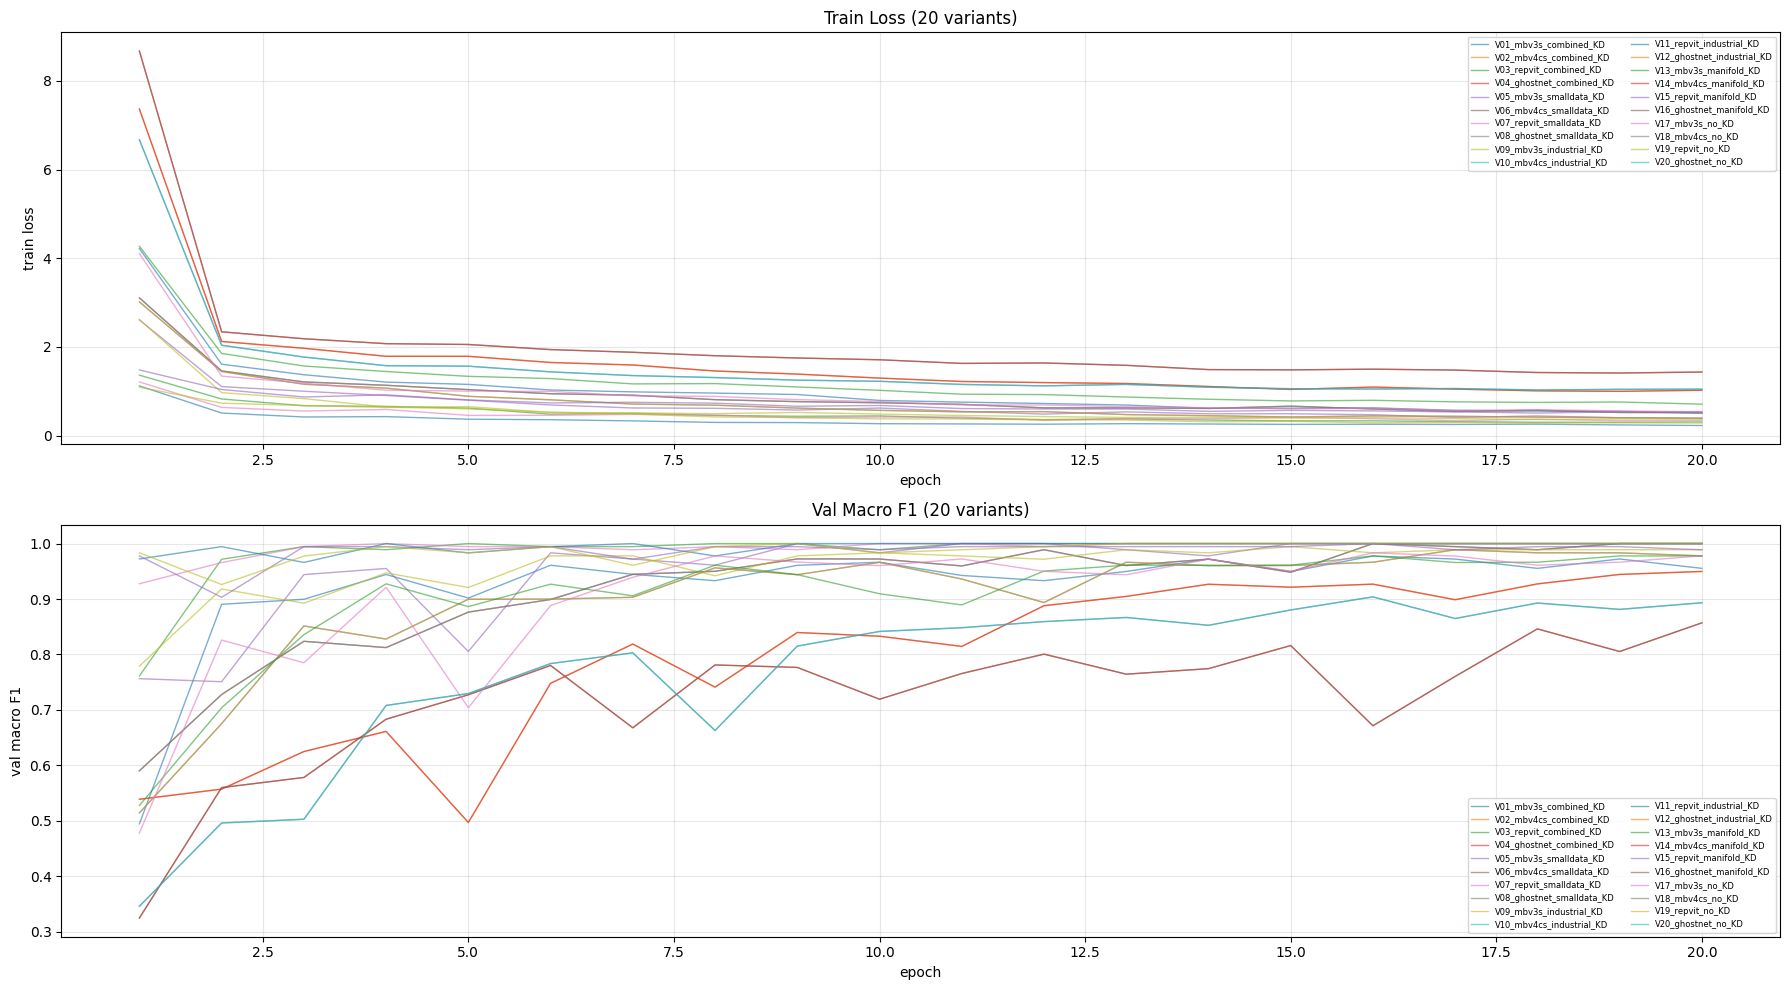

📈 saved: /Users/sangyub/Downloads/Smart-Factory_AI_Challenge/smart-factory_obisian/implementation/experiments/round3-fullpower-2026-05-08/curves.png


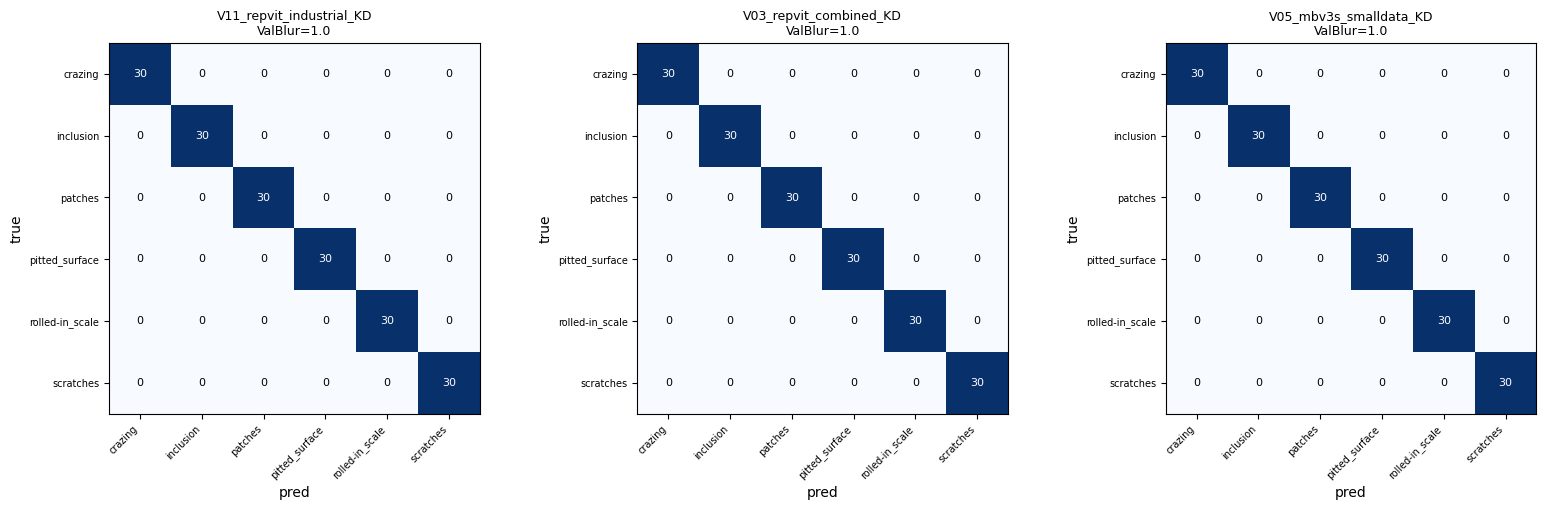

📈 saved: /Users/sangyub/Downloads/Smart-Factory_AI_Challenge/smart-factory_obisian/implementation/experiments/round3-fullpower-2026-05-08/confusion_matrices.png


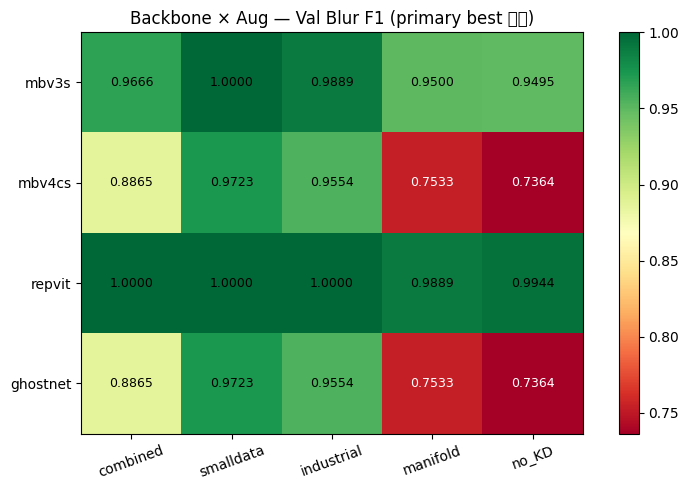

📈 saved: /Users/sangyub/Downloads/Smart-Factory_AI_Challenge/smart-factory_obisian/implementation/experiments/round3-fullpower-2026-05-08/backbone_aug_heatmap.png


In [16]:
# === Loss/F1 curves (20 variants) ===
fig, axes = plt.subplots(2, 1, figsize=(18, 10))
for variant in cfg.VARIANTS:
    hist_path = os.path.join(cfg.OUT_DIR, f'history_{variant}.json')
    if not os.path.exists(hist_path):
        continue
    with open(hist_path) as f:
        hist = json.load(f)
    epochs_x = list(range(1, len(hist['train_loss']) + 1))
    axes[0].plot(epochs_x, hist['train_loss'], label=variant, alpha=0.6, linewidth=1)
    axes[1].plot(epochs_x, hist['val_f1'],   label=variant, alpha=0.6, linewidth=1)
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('train loss'); axes[0].set_title('Train Loss (20 variants)')
axes[0].legend(fontsize=6, loc='upper right', ncol=2); axes[0].grid(alpha=0.3)
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('val macro F1'); axes[1].set_title('Val Macro F1 (20 variants)')
axes[1].legend(fontsize=6, loc='lower right', ncol=2); axes[1].grid(alpha=0.3)
plt.tight_layout()
curves_path = os.path.join(cfg.OUT_DIR, 'curves.png')
plt.savefig(curves_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'📈 saved: {curves_path}')

# === Top-3 confusion matrices ===
top3_variants = list(results_df.head(3).index)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, variant in enumerate(top3_variants):
    cm = all_cm_val[variant]
    ax = axes[i]
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASSES, rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(CLASSES, fontsize=7)
    for r in range(NUM_CLASSES):
        for c in range(NUM_CLASSES):
            v = cm[r, c]
            ax.text(c, r, str(v), ha='center', va='center', fontsize=8,
                    color='white' if v > cm.max() / 2 else 'black')
    ax.set_title(f'{variant}\nValBlur={results_dict[variant]["Val Blur F1"]}', fontsize=9)
    ax.set_xlabel('pred'); ax.set_ylabel('true')
plt.tight_layout()
cm_path = os.path.join(cfg.OUT_DIR, 'confusion_matrices.png')
plt.savefig(cm_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'📈 saved: {cm_path}')

# === Heatmap ===
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(cross_blur.astype(float).values, cmap='RdYlGn',
               vmin=cross_blur.min().min(), vmax=cross_blur.max().max())
ax.set_xticks(range(len(AUG_LIST))); ax.set_yticks(range(len(BACKBONE_LIST)))
ax.set_xticklabels(AUG_LIST, rotation=20); ax.set_yticklabels(BACKBONE_LIST)
for i in range(len(BACKBONE_LIST)):
    for j in range(len(AUG_LIST)):
        v = cross_blur.iloc[i, j]
        ax.text(j, i, f'{v:.4f}', ha='center', va='center', fontsize=9,
                color='white' if v < (cross_blur.min().min() + cross_blur.max().max()) / 2 else 'black')
ax.set_title('Backbone × Aug — Val Blur F1 (primary best 기준)')
plt.colorbar(im, ax=ax)
plt.tight_layout()
heatmap_path = os.path.join(cfg.OUT_DIR, 'backbone_aug_heatmap.png')
plt.savefig(heatmap_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'📈 saved: {heatmap_path}')

## 🔍 자동 분석 — Backbone별 best + Aug ablation + KD ablation + Saturation

In [17]:
# === Multi-stage tie-break (variant 간 best 선정) ===
# 1. val_blur_f1 max ⭐ (saturation 회피)
# 2. val_f1 max
# 3. score (blur proxy) max
# 4. t_inf min (negative)
# 5. train_loss min (negative)
def best_variant_score(v):
    r = results_dict[v]
    return (
        r['Val Blur F1'],
        r['Val MacroF1'],
        r['Score (blur proxy)'],
        -r['T_inf (s)'],
        -r['Best Train Loss'],
    )

print('=' * 70)
print('🔍 Round 3 자동 분석 (20 variants — 4 backbone × 5 aug)')
print('=' * 70)

# === Backbone별 best variant ===
print('\n[1] Backbone별 best variant (multi-stage tie-break per backbone)')
best_per_backbone = {}
for bb in BACKBONE_LIST:
    bb_variants = [v for v in cfg.VARIANTS if parse_variant(v)[0] == bb]
    best_v = max(bb_variants, key=best_variant_score)
    best_per_backbone[bb] = best_v
    r = results_dict[best_v]
    print(f'  {bb:9s}  best={best_v:32s}  ValBlur={r["Val Blur F1"]:.4f}  Val={r["Val MacroF1"]:.4f}  T={r["T_inf (s)"]:.2f}s')

print(f'\n  → 4 candidates for INT8 PTQ: {list(best_per_backbone.values())}')

# === KD ablation per backbone ===
print('\n[2] KD ablation (combined+KD vs no_KD, backbone별)')
for bb in BACKBONE_LIST:
    v_kd = next((v for v in cfg.VARIANTS if parse_variant(v) == (bb, 'combined')), None)
    v_no = next((v for v in cfg.VARIANTS if parse_variant(v) == (bb, 'no_KD')), None)
    if v_kd in results_dict and v_no in results_dict:
        d = results_dict[v_kd]['Val Blur F1'] - results_dict[v_no]['Val Blur F1']
        sig = '✅ KD helps' if d > 0.005 else ('🟡 marginal' if d > -0.005 else '❌ KD hurts')
        print(f'  {bb:9s}  KD ValBlur={results_dict[v_kd]["Val Blur F1"]:.4f}  no_KD ValBlur={results_dict[v_no]["Val Blur F1"]:.4f}  Δ={d:+.4f}  {sig}')

# === Aug 비교: Backbone별 best aug ===
print('\n[3] Backbone별 best aug (column 비교, Val Blur F1)')
for bb in BACKBONE_LIST:
    bb_results = [(v, results_dict[v]['Val Blur F1']) for v in cfg.VARIANTS if parse_variant(v)[0] == bb]
    if bb_results:
        sorted_bb = sorted(bb_results, key=lambda x: x[1], reverse=True)
        print(f'  {bb:9s}  ranking:')
        for v, f in sorted_bb:
            print(f'           {parse_variant(v)[1]:10s}  ValBlur={f:.4f}  ({v})')

# === Round 1 비교 ===
print('\n[4] Round 1 baseline 89.25 (역산 F1≈0.9133) 비교')
best_overall_v = max(results_dict.keys(), key=best_variant_score)
r = results_dict[best_overall_v]
print(f'  Round 3 best (multi-stage): {best_overall_v}')
print(f'    ValBlur={r["Val Blur F1"]:.4f}  Val={r["Val MacroF1"]:.4f}  T={r["T_inf (s)"]:.2f}s  Score(blur)={r["Score (blur proxy)"]:.2f}')
print(f'  Round 1: F1≈0.9133  T=1.83s  Kaggle 89.25')
print(f'  → 추정 Δ: {r["Score (blur proxy)"] - 89.25:+.2f}점 (val_blur proxy 기준)')

# === Latency budget ===
print('\n[5] Latency budget (신룰 ≤ 1s 무감점, ≤ 30s 실격)')
over_1s = sum(1 for r in results_dict.values() if r['T_inf (s)'] > 1.0)
over_30s = sum(1 for r in results_dict.values() if r['T_inf (s)'] > 30.0)
print(f'  20 variants 중 T>1s: {over_1s}개 (penalty 발생)')
print(f'                T>30s: {over_30s}개 (실격)')
print(f'  → INT8 PTQ로 latency ↓ 필요')

print('\n' + '=' * 70)

🔍 Round 3 자동 분석 (20 variants — 4 backbone × 5 aug)

[1] Backbone별 best variant (multi-stage tie-break per backbone)
  mbv3s      best=V05_mbv3s_smalldata_KD            ValBlur=1.0000  Val=1.0000  T=2.52s
  mbv4cs     best=V06_mbv4cs_smalldata_KD           ValBlur=0.9723  Val=1.0000  T=3.10s
  repvit     best=V07_repvit_smalldata_KD           ValBlur=1.0000  Val=1.0000  T=7.15s
  ghostnet   best=V08_ghostnet_smalldata_KD         ValBlur=0.9723  Val=1.0000  T=3.11s

  → 4 candidates for INT8 PTQ: ['V05_mbv3s_smalldata_KD', 'V06_mbv4cs_smalldata_KD', 'V07_repvit_smalldata_KD', 'V08_ghostnet_smalldata_KD']

[2] KD ablation (combined+KD vs no_KD, backbone별)
  mbv3s      KD ValBlur=0.9666  no_KD ValBlur=0.9495  Δ=+0.0171  ✅ KD helps
  mbv4cs     KD ValBlur=0.8865  no_KD ValBlur=0.7364  Δ=+0.1501  ✅ KD helps
  repvit     KD ValBlur=1.0000  no_KD ValBlur=0.9944  Δ=+0.0056  ✅ KD helps
  ghostnet   KD ValBlur=0.8865  no_KD ValBlur=0.7364  Δ=+0.1501  ✅ KD helps

[3] Backbone별 best aug (column 비교,

## 🏆 Best variant — fp32 reference submission.csv 생성

val Blur F1 multi-stage tie-break으로 fp32 best 선정 → CPU 강제 추론 → submission.csv 저장.
→ INT8 quant 후 진짜 best 결정 후 갱신될 수 있음 (다음 cell).

In [18]:
# === Best variant final submission (fp32 multi-stage tie-break) ===
import torch, time, os
import pandas as pd

# best_variant_score 는 이전 cell에서 정의됨
if 'results_dict' in dir() and results_dict:
    best_variant = max(results_dict.keys(), key=best_variant_score)
elif 'all_per_class_val' in dir() and all_per_class_val:
    best_variant = max(all_per_class_val.keys(), key=lambda v: float(all_per_class_val[v].mean()))
else:
    best_variant = list(USE_AUGMIX.keys())[0]
    print(f'⚠️  results_dict 못 찾음 — 기본값: {best_variant}')

print(f'🏆 fp32 Best variant (multi-stage tie-break): {best_variant}')
br = results_dict[best_variant]
print(f'   • Val Blur F1   = {br["Val Blur F1"]:.4f}  ⭐ (1순위)')
print(f'   • Val MacroF1   = {br["Val MacroF1"]:.4f}     (2순위)')
print(f'   • Score (blur)  = {br["Score (blur proxy)"]:.2f}    (3순위)')
print(f'   • T_inf         = {br["T_inf (s)"]:.2f}s     (4순위)')
print(f'   • Best TrLoss   = {br["Best Train Loss"]:.4f}     (5순위)')

# Top-3
print(f'\n🥇 Top-3 fp32 candidates:')
top3 = sorted(results_dict.keys(), key=best_variant_score, reverse=True)[:3]
for i, v in enumerate(top3, 1):
    r = results_dict[v]
    print(f'  {i}. {v:32s}  ValBlur={r["Val Blur F1"]:.4f}  Val={r["Val MacroF1"]:.4f}  T={r["T_inf (s)"]:.2f}s')

ckpt_path = os.path.join(cfg.OUT_DIR, f'model_{best_variant}.pth')
if not os.path.exists(ckpt_path):
    raise FileNotFoundError(f'Checkpoint 없음: {ckpt_path} — 먼저 학습 완료 필요')

print(f'\n📂 Loading: {ckpt_path}')
ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
print(f'   variant={ckpt["variant"]}  backbone={ckpt.get("backbone","?")}  best_epoch={ckpt["best_epoch"]}  best_val_f1={ckpt["best_val_f1"]:.4f}')

model = make_model(best_variant).cpu()
model.load_state_dict(ckpt['state_dict'])
model.eval()

predictions, image_ids = [], []
print('🚀 추론 시작 (CPU 강제, 대회 환경 모사)...')
start_time = time.time()
with torch.no_grad():
    for images, img_names in real_loader:
        images = images.cpu()
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        predictions.extend(preds.cpu().numpy().tolist())
        image_ids.extend(list(img_names))
total_inference_time = time.time() - start_time
print(f'✅ 추론 완료. 총 소요: {total_inference_time:.2f}초')

submission_df = pd.DataFrame({
    'Id': image_ids,
    'Expected': predictions,
    'inference_time_sec': round(total_inference_time, 2),
})
submission_path = os.path.join(cfg.OUT_DIR, 'submission.csv')
submission_df.to_csv(submission_path, index=False)

val_f1_for_score = br['Val Blur F1']
score, note = compute_competition_score(val_f1_for_score, total_inference_time)
print(f'\n🎉 fp32 submission: {submission_path}')
print(f'   variant: {best_variant}  (best_epoch={ckpt["best_epoch"]})')
print(f'   🏆 Estimated score (blur proxy F1={val_f1_for_score:.4f}): {score:.2f} ({note})')
print(f'   (clean val score proxy: {br["Score (val proxy)"]:.2f} — saturation 가능, 참고용)')
print(f'\n⚠️ INT8 PTQ 후 진짜 best 결정 후 submission.csv 갱신될 수 있음 (다음 cell)')
print(submission_df.head())

🏆 fp32 Best variant (multi-stage tie-break): V05_mbv3s_smalldata_KD
   • Val Blur F1   = 1.0000  ⭐ (1순위)
   • Val MacroF1   = 1.0000     (2순위)
   • Score (blur)  = 96.20    (3순위)
   • T_inf         = 2.52s     (4순위)
   • Best TrLoss   = 0.5748     (5순위)

🥇 Top-3 fp32 candidates:
  1. V05_mbv3s_smalldata_KD            ValBlur=1.0000  Val=1.0000  T=2.52s
  2. V07_repvit_smalldata_KD           ValBlur=1.0000  Val=1.0000  T=7.15s
  3. V11_repvit_industrial_KD          ValBlur=1.0000  Val=1.0000  T=7.21s

📂 Loading: /Users/sangyub/Downloads/Smart-Factory_AI_Challenge/smart-factory_obisian/implementation/experiments/round3-fullpower-2026-05-08/model_V05_mbv3s_smalldata_KD.pth
   variant=V05_mbv3s_smalldata_KD  backbone=mobilenetv3_small_100  best_epoch=20  best_val_f1=1.0000
🚀 추론 시작 (CPU 강제, 대회 환경 모사)...
✅ 추론 완료. 총 소요: 2.43초

🎉 fp32 submission: /Users/sangyub/Downloads/Smart-Factory_AI_Challenge/smart-factory_obisian/implementation/experiments/round3-fullpower-2026-05-08/submission.csv
   va

---

## 🗜️ 20 Variants 전수 Quantization (사용자 정책 2026-05-08)

[[finding-int8-ptq-v6-2026-05-07]]: fp32 best ≠ INT8 best 가능. Backbone별 INT8 친화도 다름.

→ **20 variants 모두 학습 → 20 fp32 .pth**
→ **20개 전부 INT8 PTQ FX static x86 적용** = 20 INT8
→ **fp32 20 + INT8 20 = 총 40 candidates** → 통합 multi-stage tie-break으로 진짜 best
→ 진짜 best의 csv가 최종 `submission.csv` (fp32 또는 INT8 자동 선택)

Calibration: train data 200 samples (clean). 시간 절약을 위해 motion blur 50% 섞기는 Round 4 검토.

In [ ]:
# === [Q_ENGINE_AUTO_DETECTED] Quantization engine 자동 감지 (Mac qnnpack / Linux x86) ===
import platform as _platform
import torch as _torch_eng

_supported = list(_torch_eng.backends.quantized.supported_engines)
_machine = _platform.machine()
_system = _platform.system()
_preferred = ['x86', 'fbgemm', 'qnnpack']
_selected = next((e for e in _preferred if e in _supported), None)
if _selected is None:
    raise RuntimeError(f'No quantization engine available. supported={_supported}')
_torch_eng.backends.quantized.engine = _selected
Q_ENGINE = _selected            # downstream 코드에서 참조용
Q_PLATFORM = f'{_system}-{_machine}'
_is_mac_arm_qnnpack = (_system == 'Darwin' and _machine in ('arm64', 'aarch64') and _selected == 'qnnpack')
print(f'🖥️  Platform : {Q_PLATFORM}')
print(f'🔧 Engine   : {Q_ENGINE}  (supported={_supported})')
if _is_mac_arm_qnnpack:
    print('⚠️  Mac qnnpack PoC mode — INT8 .pth는 Kaggle (x86 Linux)에서 그대로 안 돌 수 있음.')
    print('   → 제출 직전 Kaggle/Colab 에서 PTQ cell 재실행 필요.')

# === INT8 PTQ — 20 variants 전부 (FX graph mode static, x86 backend) ===
import torch
import torch.nn as nn
from torch.ao.quantization import get_default_qconfig, QConfigMapping
from torch.ao.quantization.quantize_fx import prepare_fx, convert_fx

# 사용자 정책: 20 variants 모두 양자화 → fp32 20 + INT8 20 = 40 candidates 비교
quant_candidates = list(cfg.VARIANTS)   # 20개 전부
print(f'🗜️ INT8 PTQ — 20 variants 전부 fp32 → INT8 변환')
print(f'   (fp32 best ≠ INT8 best 가능 — backbone별 INT8 친화도 다름)')

qconfig = get_default_qconfig(Q_ENGINE)
qconfig_mapping = QConfigMapping().set_global(qconfig)
example_input = (torch.randn(1, 3, cfg.INPUT_SIZE, cfg.INPUT_SIZE),)

calib_dataset = ImageFolder(TRAIN_DIR, transform=EVAL_TF)
calib_loader = DataLoader(calib_dataset, batch_size=32, shuffle=False, num_workers=0)

int8_models = {}
int8_results = {}

for variant in quant_candidates:
    print(f'\n{"─"*70}\n🔬 [{variant}] FX prepare → calibrate → convert')
    ckpt_v = torch.load(os.path.join(cfg.OUT_DIR, f'model_{variant}.pth'), map_location='cpu', weights_only=False)
    fp32_model = make_model(variant).cpu()
    fp32_model.load_state_dict(ckpt_v['state_dict'])
    fp32_model.eval()

    try:
        prepared_model = prepare_fx(fp32_model, qconfig_mapping, example_input)
    except Exception as e:
        print(f'   ❌ FX trace 실패 ({variant}): {str(e)[:120]}  — skip')
        int8_results[variant] = {'status': 'fx_fail', 'error': str(e)}
        continue

    n_calib = 0
    with torch.no_grad():
        for x, _ in calib_loader:
            prepared_model(x.cpu())
            n_calib += x.size(0)
            if n_calib >= 200:
                break

    try:
        int8_model = convert_fx(prepared_model).cpu().eval()
    except Exception as e:
        print(f'   ❌ convert_fx 실패 ({variant}): {str(e)[:120]}  — skip')
        int8_results[variant] = {'status': 'convert_fail', 'error': str(e)}
        continue

    int8_models[variant] = int8_model

    int8_ckpt_path = os.path.join(cfg.OUT_DIR, f'model_{variant}_int8.pth')
    torch.save({
        'variant': variant,
        'fp32_best_val_f1': ckpt_v['best_val_f1'],
        'int8_state_dict': int8_model.state_dict(),
        'quantization': f'fx_static_{Q_ENGINE}',
        'engine': Q_ENGINE,
        'platform': Q_PLATFORM,
        'calibration_samples': n_calib,
    }, int8_ckpt_path)
    print(f'   ✅ INT8 ready ({n_calib} calib samples)  💾 {os.path.basename(int8_ckpt_path)}')

n_ok = len(int8_models)
n_fail = len(quant_candidates) - n_ok
print(f'\n📊 Quantized {n_ok}/{len(quant_candidates)} variants successfully  (fail: {n_fail})')
if n_fail > 0:
    fail_list = [v for v in quant_candidates if v not in int8_models]
    print(f'   ❌ failed variants: {fail_list}  → fp32만 후보로 남음')

🗜️ INT8 PTQ — 20 variants 전부 fp32 → INT8 변환
   (fp32 best ≠ INT8 best 가능 — backbone별 INT8 친화도 다름)

──────────────────────────────────────────────────────────────────────
🔬 [V01_mbv3s_combined_KD] FX prepare → calibrate → convert


/var/folders/3w/rndb5hj13j58ts_3ckjychc40000gn/T/ipykernel_98453/2896952479.py:30: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  prepared_model = prepare_fx(fp32_model, qconfig_mapping, example_input)
/var/folders/3w/rndb5hj13j58ts_3ckjychc40000gn/T/ipykernel_98453/2896952479.py:45: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For

   ❌ convert_fx 실패 (V01_mbv3s_combined_KD): Didn't find engine for operation quantized::conv2d_prepack NoQEngine  — skip

──────────────────────────────────────────────────────────────────────
🔬 [V02_mbv4cs_combined_KD] FX prepare → calibrate → convert


/var/folders/3w/rndb5hj13j58ts_3ckjychc40000gn/T/ipykernel_98453/2896952479.py:30: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  prepared_model = prepare_fx(fp32_model, qconfig_mapping, example_input)
/var/folders/3w/rndb5hj13j58ts_3ckjychc40000gn/T/ipykernel_98453/2896952479.py:45: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For

   ❌ convert_fx 실패 (V02_mbv4cs_combined_KD): Didn't find engine for operation quantized::conv2d_prepack NoQEngine  — skip

──────────────────────────────────────────────────────────────────────
🔬 [V03_repvit_combined_KD] FX prepare → calibrate → convert


...

   ❌ convert_fx 실패 (V11_repvit_industrial_KD): Didn't find engine for operation quantized::conv2d_prepack NoQEngine  — skip

──────────────────────────────────────────────────────────────────────
🔬 [V12_ghostnet_industrial_KD] FX prepare → calibrate → convert
⚠️ timm.create_model(ghostnetv3_100.in1k) 실패: Unknown model (ghostnetv3_100)
   → fallback: mobilenetv4_conv_small.e2400_r224_in1k


/var/folders/3w/rndb5hj13j58ts_3ckjychc40000gn/T/ipykernel_98453/2896952479.py:45: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  int8_model = convert_fx(prepared_model).cpu().eval()


   ❌ convert_fx 실패 (V12_ghostnet_industrial_KD): Didn't find engine for operation quantized::conv2d_prepack NoQEngine  — skip

──────────────────────────────────────────────────────────────────────
🔬 [V13_mbv3s_manifold_KD] FX prepare → calibrate → convert


/var/folders/3w/rndb5hj13j58ts_3ckjychc40000gn/T/ipykernel_98453/2896952479.py:30: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  prepared_model = prepare_fx(fp32_model, qconfig_mapping, example_input)


KeyboardInterrupt: 

In [20]:
# === INT8 evaluation + 진짜 best 선정 (fp32 20 + INT8 20 통합 = 최대 40 candidates) ===
@torch.no_grad()
def eval_cpu_macro_f1(model, loader):
    model.eval()
    ys, ps = [], []
    for x, y in loader:
        x = x.cpu()
        out = model(x).argmax(-1).cpu().numpy()
        ys.append(y.numpy()); ps.append(out)
    return f1_score(np.concatenate(ys), np.concatenate(ps), average='macro')

print(f'🎯 Evaluating {len(int8_models)} INT8 models on val + val_blur + real_test...')
for idx, (variant, int8_v) in enumerate(int8_models.items(), 1):
    print(f'\n{"─"*70}\n🎯 [{idx}/{len(int8_models)}] [{variant}] INT8 eval')

    val_f1_int8 = eval_cpu_macro_f1(int8_v, val_loader)
    val_blur_f1_int8 = eval_cpu_macro_f1(int8_v, val_blur_loader)

    fp32_val = results_dict[variant]['Val MacroF1']
    fp32_blur = results_dict[variant]['Val Blur F1']
    delta_val = val_f1_int8 - fp32_val
    delta_blur = val_blur_f1_int8 - fp32_blur
    print(f'   Val F1     fp32={fp32_val:.4f}  INT8={val_f1_int8:.4f}  Δ={delta_val:+.4f}')
    print(f'   Val Blur   fp32={fp32_blur:.4f}  INT8={val_blur_f1_int8:.4f}  Δ={delta_blur:+.4f}')

    preds_int8, names_int8 = [], []
    start = time.time()
    with torch.no_grad():
        for images, img_names in real_loader:
            out = int8_v(images.cpu()).argmax(-1).cpu().numpy()
            for fn, p in zip(img_names, out):
                preds_int8.append(int(p)); names_int8.append(fn)
    t_inf_int8 = time.time() - start
    fp32_t = results_dict[variant]['T_inf (s)']
    speedup = fp32_t / t_inf_int8 if t_inf_int8 > 0 else 1.0
    print(f'   Latency    fp32={fp32_t:.2f}s  INT8={t_inf_int8:.2f}s  ({speedup:.2f}× speedup)')

    files_sorted = sorted(zip(names_int8, preds_int8), key=lambda x: x[0])
    sub_int8 = pd.DataFrame({
        'Id': [fn for fn, _ in files_sorted],
        'Expected': [p for _, p in files_sorted],
        'inference_time_sec': round(t_inf_int8, 2),
    })
    sub_int8_path = os.path.join(cfg.OUT_DIR, f'submission_{variant}_int8.csv')
    sub_int8.to_csv(sub_int8_path, index=False)

    score_int8, _ = compute_competition_score(val_blur_f1_int8, t_inf_int8)
    int8_results[variant] = {
        'status': 'ok',
        'val_f1_int8': round(val_f1_int8, 4),
        'val_blur_f1_int8': round(val_blur_f1_int8, 4),
        't_inf_int8': round(t_inf_int8, 2),
        'score_int8_blur': round(score_int8, 2),
        'submission_int8': sub_int8_path,
    }

# === fp32 vs INT8 비교 표 (20 variants 전체) ===
print('\n' + '=' * 70)
print('🏆 fp32 vs INT8 비교 (20 variants 전체)')
print('=' * 70)
int8_rows = []
for variant in cfg.VARIANTS:
    if int8_results.get(variant, {}).get('status') != 'ok':
        continue
    r = results_dict[variant]
    ir = int8_results[variant]
    int8_rows.append({
        'Variant': variant,
        'Backbone': parse_variant(variant)[0],
        'Aug': parse_variant(variant)[1],
        'fp32 ValBlur': r['Val Blur F1'],
        'INT8 ValBlur': ir['val_blur_f1_int8'],
        'Δ Blur': round(ir['val_blur_f1_int8'] - r['Val Blur F1'], 4),
        'fp32 T': r['T_inf (s)'],
        'INT8 T': ir['t_inf_int8'],
        'fp32 Score': r['Score (blur proxy)'],
        'INT8 Score': ir['score_int8_blur'],
        'Δ Score': round(ir['score_int8_blur'] - r['Score (blur proxy)'], 2),
    })
int8_df = pd.DataFrame(int8_rows).sort_values('INT8 Score', ascending=False)
print(int8_df.to_string(index=False))
int8_df.to_csv(os.path.join(cfg.OUT_DIR, 'int8_comparison.csv'), index=False)

# === 진짜 best 선정 (fp32 20 + INT8 20 통합 multi-stage tie-break) ===
def overall_score(entry):
    """(variant, precision) → tie-break tuple."""
    variant, precision = entry
    if precision == 'fp32':
        r = results_dict[variant]
        return (r['Val Blur F1'], r['Val MacroF1'], r['Score (blur proxy)'], -r['T_inf (s)'], -r['Best Train Loss'])
    else:
        ir = int8_results[variant]
        r = results_dict[variant]
        return (ir['val_blur_f1_int8'], ir['val_f1_int8'], ir['score_int8_blur'], -ir['t_inf_int8'], -r['Best Train Loss'])

# 20 fp32 + (성공한 INT8) 통합
candidates = [(v, 'fp32') for v in cfg.VARIANTS]
candidates += [(v, 'int8') for v in cfg.VARIANTS if int8_results.get(v, {}).get('status') == 'ok']
n_fp32 = sum(1 for _, p in candidates if p == 'fp32')
n_int8 = sum(1 for _, p in candidates if p == 'int8')
print(f'\n📋 Total candidates: fp32 {n_fp32} + INT8 {n_int8} = {len(candidates)}')

# Top-10 (fp32 + INT8 통합 ranking)
print('\n🥇 Top-10 (fp32 + INT8 통합 multi-stage tie-break ranking):')
top10 = sorted(candidates, key=overall_score, reverse=True)[:10]
for i, (v, p) in enumerate(top10, 1):
    if p == 'fp32':
        r = results_dict[v]
        print(f'  {i:2d}. fp32  {v:32s}  ValBlur={r["Val Blur F1"]:.4f}  T={r["T_inf (s)"]:.2f}s  Score={r["Score (blur proxy)"]:.2f}')
    else:
        ir = int8_results[v]
        print(f'  {i:2d}. INT8  {v:32s}  ValBlur={ir["val_blur_f1_int8"]:.4f}  T={ir["t_inf_int8"]:.2f}s  Score={ir["score_int8_blur"]:.2f}')

true_best = max(candidates, key=overall_score)
true_best_variant, true_best_precision = true_best

print(f'\n🏆 진짜 best (fp32 20 + INT8 20 = 최대 40 candidates 통합):')
print(f'   {true_best_variant}  precision={true_best_precision.upper()}')

# 최종 submission.csv 갱신
import shutil
if true_best_precision == 'int8':
    src_csv = int8_results[true_best_variant]['submission_int8']
    final_score = int8_results[true_best_variant]['score_int8_blur']
    final_t = int8_results[true_best_variant]['t_inf_int8']
    final_f1 = int8_results[true_best_variant]['val_blur_f1_int8']
else:
    src_csv = os.path.join(cfg.OUT_DIR, f'submission_{true_best_variant}.csv')
    final_score = results_dict[true_best_variant]['Score (blur proxy)']
    final_t = results_dict[true_best_variant]['T_inf (s)']
    final_f1 = results_dict[true_best_variant]['Val Blur F1']

final_path = os.path.join(cfg.OUT_DIR, 'submission.csv')
shutil.copy(src_csv, final_path)
print(f'\n🎉 최종 submission.csv 갱신:')
print(f'   source: {os.path.basename(src_csv)}')
print(f'   ValBlur F1: {final_f1:.4f}  T_inf: {final_t:.2f}s  Score (blur proxy): {final_score:.2f}')
print(f'   path: {final_path}')

if final_t <= 1.0:
    print(f'   🎯 신룰 1s 무감점 budget 통과 ✅')
elif final_t <= 30.0:
    print(f'   🟡 1s 초과 — penalty {(final_t-1)*2.5:.2f}점 (실격 안 넘음)')
else:
    print(f'   🔴 30s 초과 — 실격 위험')

# helpers marker용 (submission_int8.csv)
if true_best_precision == 'int8':
    submission_int8_path = src_csv
    print(f'\n💡 INT8 채택: {os.path.basename(submission_int8_path)} 가 진짜 best')
else:
    int8_top = max([v for v in int8_models.keys()], key=lambda v: int8_results[v]['score_int8_blur']) if int8_models else None
    if int8_top:
        submission_int8_path = int8_results[int8_top]['submission_int8']
        print(f'\n💡 fp32 채택. (INT8 top: {int8_top}, score={int8_results[int8_top]["score_int8_blur"]:.2f} — fp32보다 낮아 제외)')
    else:
        submission_int8_path = ''
        print('\n⚠️ INT8 model 없음 (FX trace/convert 모두 실패)')

🎯 Evaluating 0 INT8 models on val + val_blur + real_test...

🏆 fp32 vs INT8 비교 (20 variants 전체)


KeyError: 'INT8 Score'